# 유방암 분류 모델 평가와 오류 분석
accuracy를 넘어서 FN, recall, threshold까지 이해하기

## 1. 라이브러리 불러오기

In [5]:
# 숫자 계산(평균, 배열 처리 등)에 사용하는 numpy 입니다.
# 보통 np 라는 짧은 별칭으로 줄여서 사용합니다. (관례)
import numpy as np

# 데이터를 표(엑셀 같은 형태)로 다루기 위한 pandas 입니다.
# 보통 pd 라는 짧은 별칭으로 사용합니다.
import pandas as pd

# 그래프를 그리기 위한 matplotlib의 pyplot 모듈입니다.
# plt 라는 별칭으로 사용하는 것이 관례입니다.
import matplotlib.pyplot as plt

# matplotlib을 더 보기 좋게 그려주는 시각화 라이브러리 seaborn 입니다.
# 이번에는 confusion matrix를 색칠한 표(heatmap)로 그릴 때 사용합니다.
import seaborn as sns

# sklearn에서 제공하는 유방암 예제 데이터를 불러오는 함수입니다.
from sklearn.datasets import load_breast_cancer

# 데이터를 학습용/평가용으로 나누는 함수입니다.
# (모델이 '공부한 데이터'가 아니라 '처음 보는 데이터'로 실력을 재기 위해 필요합니다.)
from sklearn.model_selection import train_test_split

# 모델 성능을 평가할 때 사용할 지표 함수들을 한 번에 불러옵니다.
from sklearn.metrics import (
    accuracy_score,          # 정확도: 전체 중 맞힌 비율
    confusion_matrix,        # 혼동 행렬: 맞힘/틀림을 4칸 표로 정리
    classification_report,   # 클래스별 precision/recall/f1 등을 한 번에 출력
    precision_score,         # 정밀도
    recall_score,            # 재현율
    f1_score                 # precision과 recall을 함께 본 점수
)

# 이번 강의에서 사용할 분류 모델인 XGBoost 입니다.
from xgboost import XGBClassifier

In [6]:
# 그래프 안의 마이너스 기호가 네모로 깨지는 것을 방지하는 설정입니다.
plt.rcParams["axes.unicode_minus"] = False
# 그래프 한글 글자체 설정
plt.rcParams["font.family"] = "Malgun Gothic"

## 2. 데이터 불러오기와 target 변환

In [7]:
# 유방암 예제 데이터를 불러옵니다.
data = load_breast_cancer()

# data.data           : feature(입력 정보) 숫자들
# data.feature_names  : feature들의 이름
# 이 둘을 합쳐서 표(DataFrame) 형태로 만듭니다.
df = pd.DataFrame(data.data, columns=data.feature_names)

# ----- 원본 target 보존 -----
# 원래 sklearn 기준: 0 = malignant(악성), 1 = benign(양성)
df["target_original"] = data.target

# ----- 수업용 target 생성 -----
# 0과 1을 서로 뒤집습니다. (1 - 0 = 1,  1 - 1 = 0)
# 수업용 기준: 0 = benign(양성), 1 = malignant(악성)
df["target"] = 1 - df["target_original"]

# ----- 사람이 읽기 쉬운 이름 컬럼 추가 -----
# 숫자 0/1 대신 글자로 보면 의미를 바로 이해할 수 있습니다.
df["target_name"] = df["target"].map({
    0: "benign",
    1: "malignant"
})

# 표의 크기(행 개수, 열 개수)를 확인합니다.
print("데이터 크기 (행, 열):", df.shape)

데이터 크기 (행, 열): (569, 33)


In [8]:
# 변환이 제대로 되었는지 직접 눈으로 확인합니다.
# target_original(원본)과 target(수업용)이 서로 반대 값인지 봅니다.
df[["target_original", "target", "target_name"]].head()

,target_original,target,target_name
0,0,1,malignant
1,0,1,malignant
2,0,1,malignant
3,0,1,malignant
4,0,1,malignant


In [9]:
# 수업용 target 기준으로 양성/악성이 각각 몇 개인지 세어 봅니다.
df["target_name"].value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

## 3. feature와 target 나누기 (X와 y)

In [10]:
# X : 입력 정보(feature)들만 모읍니다.
#     정답과 관련된 컬럼 3개는 반드시 제외합니다. (데이터 누수 방지)
X = df.drop(columns=["target_original", "target", "target_name"])

# y : 모델이 맞혀야 하는 정답. 수업용 target을 사용합니다. (0=benign, 1=malignant)
y = df["target"]

# X에 정답 컬럼이 실수로 들어가지 않았는지 확인합니다.
print("X의 열 개수:", X.shape[1])
print("정답 관련 컬럼이 X에 있나요?",
      any(col in X.columns for col in ["target_original", "target", "target_name"]))

X의 열 개수: 30
정답 관련 컬럼이 X에 있나요? False


## 4. 모델 학습을 위한 데이터 준비 (train/test split과 stratify)

In [11]:
# 데이터를 학습용(train)과 평가용(test)으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # 입력 정보
    y,                  # 정답 (0=benign, 1=malignant)
    test_size=0.2,       # 전체의 20%를 평가용으로 사용
    random_state=42,     # 나누는 방식을 고정해서 매번 같은 결과가 나오게 함
    stratify=y           # 양성/악성 비율을 train/test에 비슷하게 유지
)

# 나눈 결과의 크기를 확인합니다.
print("학습용 데이터 개수:", X_train.shape[0])
print("평가용 데이터 개수:", X_test.shape[0])

학습용 데이터 개수: 455
평가용 데이터 개수: 114


## 5. XGBoost 분류 모델 학습과 예측 (predict()와 predict_proba())

In [12]:
# XGBoost 분류 모델을 만듭니다. (기본 설정)
model = XGBClassifier(
    random_state=42,        # 결과를 매번 같게 만들기 위한 고정값
    eval_metric="logloss",  # 학습 중 사용하는 평가 방식 (경고 메시지를 줄여줌)
    n_jobs=1                # 사용할 CPU 코어 수를 1개로 고정합니다.
    # 수업용 노트북에서는 실행 환경에 따라 XGBoost가 너무 많은 CPU 자원을 사용하거나
    # 멈춘 것처럼 보일 수 있습니다.
    # 따라서 안정적인 실행을 위해 n_jobs=1을 지정합니다.
)

# 학습용 데이터로 모델을 학습시킵니다.
# fit = '학습한다'는 뜻입니다. 모델이 X_train을 보고 y_train(정답)을 맞히는 규칙을 익힙니다.
model.fit(X_train, y_train)

# 학습이 끝난 모델로, 처음 보는 평가용 데이터(X_test)의 정답을 예측합니다.
# y_pred = 모델이 예측한 답 (0=benign, 1=malignant)
y_pred = model.predict(X_test)

# ----- 예측 확률도 함께 구해 둡니다. -----
# predict_proba()는 각 데이터가 '각 클래스일 확률'을 함께 반환합니다.
#   - 결과의 0번째 열 = benign(0)일 확률
#   - 결과의 1번째 열 = malignant(1)일 확률
# 우리는 악성(malignant)일 확률에 관심이 있으므로 [:, 1] 로 1번째 열만 가져옵니다.
# (현재 이 노트북에서는 0 = benign, 1 = malignant 입니다.
#  이 malignant 확률은 뒤에서 threshold(예측 기준값)를 조정할 때 핵심 재료가 됩니다.)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 예측이 끝났다는 것을 확인합니다.
print("예측 완료! 예측한 데이터 개수:", len(y_pred))
print("예측값 예시 (앞 10개):", y_pred[:10])
print("malignant 확률 예시 (앞 5개):", y_pred_proba[:5].round(3))

예측 완료! 예측한 데이터 개수: 114
예측값 예시 (앞 10개): [0 1 0 1 0 0 1 0 0 0]
malignant 확률 예시 (앞 5개): [0.001 1.    0.027 0.992 0.021]


## 6. accuracy와 confusion matrix로 기본 평가하기 (TN, FP, FN, TP)

In [13]:
# accuracy(정확도) = 맞힌 개수 / 전체 개수
accuracy = accuracy_score(y_test, y_pred)

# 보기 좋게 비율(%)로도 함께 출력합니다.
print("accuracy:", accuracy)
print(f"즉, 전체의 약 {accuracy*100:.1f}% 를 맞혔습니다.")

accuracy: 0.956140350877193
즉, 전체의 약 95.6% 를 맞혔습니다.


In [14]:
# 클래스 이름의 순서를 직접 고정합니다.
# 절대 data.target_names 를 그대로 쓰지 않습니다.
# (원본은 ['malignant', 'benign'] 순서라서, target을 뒤집은 우리 기준과 어긋납니다.)
# 우리 기준: 0 = benign, 1 = malignant
class_names = ["benign", "malignant"]

# confusion matrix를 계산합니다.
# labels=[0, 1] 로 순서를 고정해서, 0번(benign)이 먼저, 1번(malignant)이 나중에 오게 합니다.
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

# 계산된 표를 숫자로 먼저 확인합니다.
print(cm)

[[72  0]
 [ 5 37]]


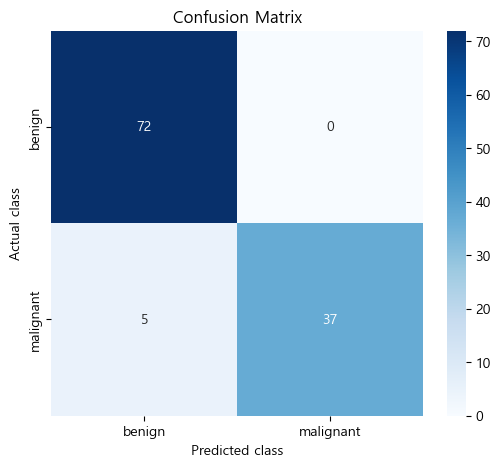

In [15]:
# confusion matrix를 색칠한 표(heatmap)로 그려서 한눈에 보기 쉽게 만듭니다.
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,                          # 위에서 계산한 4칸 표
    annot=True,                  # 각 칸에 숫자를 직접 표시
    fmt="d",                     # 숫자를 정수 형태로 표시
    cmap="Blues",                # 파란색 계열로 색칠 (값이 클수록 진하게)
    xticklabels=class_names,     # x축(예측값) 라벨: ['benign', 'malignant']
    yticklabels=class_names      # y축(실제값) 라벨: ['benign', 'malignant']
)

# 축 이름을 분명히 적습니다. (행=실제값, 열=예측값)
plt.xlabel("Predicted class")   # 가로축 = 모델의 예측
plt.ylabel("Actual class")      # 세로축 = 실제 정답
plt.title("Confusion Matrix")
plt.show()

## 7. classification report로 precision과 recall 이해하기

In [16]:
# 클래스별 precision / recall / f1-score 등을 한 번에 출력합니다.
# labels와 target_names를 직접 지정해서 우리 기준(0=benign, 1=malignant)에 맞춥니다.
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      benign       0.94      1.00      0.97        72
   malignant       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



## 8. 틀린 예측 데이터 분석하기 (FN과 FP 데이터를 직접 확인하기)

In [17]:
# 인덱스(행 번호)를 0부터 새로 매겨서 짝이 어긋나지 않게 만듭니다.
X_test_reset = X_test.reset_index(drop=True).copy()
y_test_reset = y_test.reset_index(drop=True)   # y_test는 pandas Series 입니다.

# 예측 결과를 담을 표를 X_test_reset 복사본으로 시작합니다.
result_df = X_test_reset.copy()

# 실제 정답과 모델의 예측을 컬럼으로 추가합니다.
result_df["y_true"] = y_test_reset    # 실제값 (0=benign, 1=malignant)
result_df["y_pred"] = y_pred          # 예측값 (0=benign, 1=malignant)

# 모델이 계산한 malignant(악성)일 확률도 컬럼으로 추가합니다.
# (앞에서 구한 y_pred_proba 입니다. 0~1 사이 값이며 1에 가까울수록 악성일 확률이 높습니다.)
result_df["malignant_probability"] = y_pred_proba

# 숫자 대신 글자로도 볼 수 있게 이름 컬럼을 추가합니다.
result_df["y_true_name"] = result_df["y_true"].map({0: "benign", 1: "malignant"})
result_df["y_pred_name"] = result_df["y_pred"].map({0: "benign", 1: "malignant"})

# 맞혔는지 여부를 True/False로 표시합니다. (실제값 == 예측값 이면 맞힘)
result_df["is_correct"] = result_df["y_true"] == result_df["y_pred"]

# 결과를 확인합니다. (뒤쪽의 정답/예측 관련 컬럼만 보면 이해하기 쉽습니다.)
result_df[["y_true", "y_pred", "y_true_name", "y_pred_name", "malignant_probability", "is_correct"]].head()

,y_true,y_pred,y_true_name,y_pred_name,malignant_probability,is_correct
0,0,0,benign,benign,0.001450,True
1,1,1,malignant,malignant,0.999753,True
2,0,0,benign,benign,0.026840,True
3,1,1,malignant,malignant,0.991571,True
4,0,0,benign,benign,0.021128,True


In [18]:
# is_correct 가 False인 행, 즉 틀린 데이터만 골라냅니다.
wrong_df = result_df[result_df["is_correct"] == False]

# 틀린 예측이 몇 개인지 먼저 출력합니다.
print("틀린 예측 개수:", len(wrong_df))

# 틀린 데이터가 있을 때만 표를 보여줍니다. (없어도 오류가 나지 않게 처리)
if len(wrong_df) == 0:
    print("이번 test split에서는 틀린 예측이 발생하지 않았습니다.")
else:
    # 보고 싶은 컬럼 목록입니다.
    # 실제/예측 클래스, 모델이 계산한 malignant 확률, 그리고 크기/면적 관련 주요 feature를 함께 봅니다.
    important_columns = [
        "y_true_name",
        "y_pred_name",
        "malignant_probability",
        "mean radius",
        "mean perimeter",
        "mean area",
        "worst radius",
        "worst perimeter",
        "worst area",
        "worst concave points"
    ]

    # 혹시 데이터에 없는 컬럼명이 있어도 KeyError가 나지 않도록,
    # 실제로 wrong_df 안에 존재하는 컬럼만 골라 둡니다.
    available_columns = [col for col in important_columns if col in wrong_df.columns]

    # 틀린 데이터를 예측 확률, 주요 feature와 함께 보여줍니다.
    # malignant_probability가 0.5 근처라면 모델이 그만큼 헷갈렸다는 뜻으로 볼 수 있습니다.
    display(wrong_df[available_columns].round(3))

틀린 예측 개수: 5


,y_true_name,y_pred_name,malignant_probability,mean radius,mean perimeter,mean area,worst radius,worst perimeter,worst area,worst concave points
16,malignant,benign,0.002,13.80,90.43,584.1,16.57,110.3,812.4,0.138
24,malignant,benign,0.454,14.48,94.25,648.2,16.21,108.4,808.9,0.122
42,malignant,benign,0.490,14.60,93.97,664.7,15.79,102.2,758.2,0.136
69,malignant,benign,0.383,12.45,82.57,477.1,15.47,103.4,741.6,0.174
112,malignant,benign,0.235,15.12,98.78,716.6,17.77,117.7,989.5,0.125


In [19]:
# false negative : 실제 malignant(1) 이지만 모델이 benign(0)으로 예측한 경우
false_negative_df = result_df[
    (result_df["y_true"] == 1) &
    (result_df["y_pred"] == 0)
]

# 개수를 먼저 출력합니다.
print("False Negative 개수:", len(false_negative_df))

# 비어 있어도 오류가 나지 않게 처리합니다.
if len(false_negative_df) == 0:
    print("이번 test split에서는 false negative가 발생하지 않았습니다.")
else:
    display(false_negative_df[["y_true_name", "y_pred_name"]])

False Negative 개수: 5


,y_true_name,y_pred_name
16,malignant,benign
24,malignant,benign
42,malignant,benign
69,malignant,benign
112,malignant,benign


In [20]:
# false positive : 실제 benign(0) 이지만 모델이 malignant(1)로 예측한 경우
false_positive_df = result_df[
    (result_df["y_true"] == 0) &
    (result_df["y_pred"] == 1)
]

# 개수를 먼저 출력합니다.
print("False Positive 개수:", len(false_positive_df))

# 비어 있어도 오류가 나지 않게 처리합니다.
if len(false_positive_df) == 0:
    print("이번 test split에서는 false positive가 발생하지 않았습니다.")
else:
    display(false_positive_df[["y_true_name", "y_pred_name"]])

False Positive 개수: 0
이번 test split에서는 false positive가 발생하지 않았습니다.


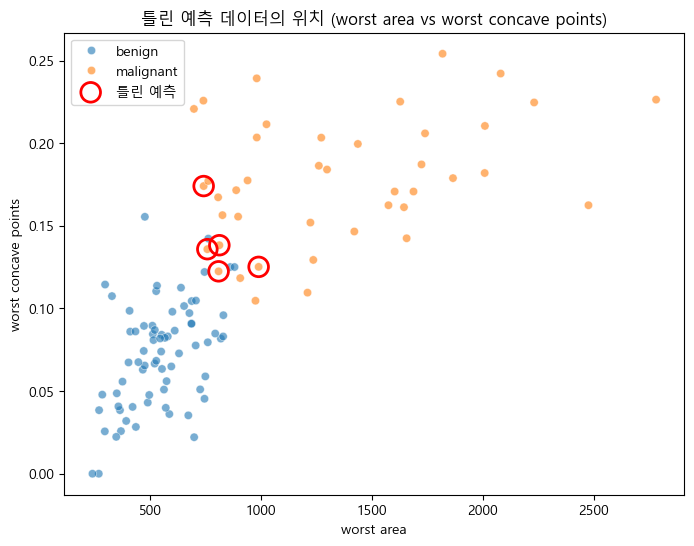

In [21]:
plt.figure(figsize=(8, 6))

# (1) 전체 test 데이터를 실제 class별로 색을 다르게 해서 점으로 그립니다.
sns.scatterplot(
    data=result_df,
    x="worst area",
    y="worst concave points",
    hue="y_true_name",       # 실제 class에 따라 색 구분
    alpha=0.6                # 점을 약간 투명하게 (겹침을 보기 위해)
)

# (2) 틀린 데이터만 그 위에 크게 한 번 더 표시합니다. (있을 때만)
if len(wrong_df) > 0:
    plt.scatter(
        wrong_df["worst area"],
        wrong_df["worst concave points"],
        s=200,                  # 점 크기를 크게
        facecolors="none",      # 속은 비우고
        edgecolors="red",       # 테두리만 빨간색
        linewidths=2,
        label="틀린 예측"
    )
else:
    print("이번 test split에서는 틀린 예측이 없어 별도로 표시할 점이 없습니다.")

# 그래프 제목과 축 이름, 범례를 분명히 표시합니다.
plt.title("틀린 예측 데이터의 위치 (worst area vs worst concave points)")
plt.xlabel("worst area")
plt.ylabel("worst concave points")
plt.legend()
plt.show()

## 9. PCA로 benign과 malignant 분포 시각화하기 (StandardScaler와 PCA)

In [22]:
# PCA와 데이터 스케일 조정을 위한 도구를 불러옵니다.
from sklearn.preprocessing import StandardScaler   # feature들의 크기(스케일)를 맞춰 주는 도구
from sklearn.decomposition import PCA               # 여러 feature를 적은 축으로 요약해 주는 도구

# 1) StandardScaler : 각 feature를 평균 0, 표준편차 1 정도로 맞춰 줍니다.
#    PCA는 값의 크기(스케일)에 민감합니다. 예를 들어 'area'는 수백~수천, 'smoothness'는 0~1 수준이라
#    그대로 두면 큰 숫자를 가진 feature가 PCA 결과를 지나치게 좌우할 수 있습니다.
#    그래서 PCA 전에 스케일을 맞춰 주는 것이 중요합니다.
scaler = StandardScaler()

# 2) fit_transform 은 train 데이터에만 사용합니다.
#    fit = '기준(평균/표준편차)을 학습', transform = '그 기준으로 변환' 입니다.
#    train으로 기준을 정하고, 그 기준을 그대로 test에 적용해야 공정합니다.
X_train_scaled = scaler.fit_transform(X_train)

# 3) test 에는 transform 만 사용합니다.
#    test로 기준을 다시 학습하면, 평가용 데이터의 정보가 새어 들어가 공정하지 않습니다.
#    그래서 train에서 정한 기준을 그대로 적용(transform)만 합니다.
X_test_scaled = scaler.transform(X_test)

# 4) PCA(n_components=2) : 30개 feature를 2개의 축(PC1, PC2)으로 요약합니다.
#    n_components=2 는 "2차원으로 줄여서 그래프로 그릴 수 있게 하겠다"는 뜻입니다.
pca = PCA(n_components=2)

# PCA도 train으로 기준을 학습(fit)하고, train/test를 같은 기준으로 변환(transform)합니다.
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA 변환 후 학습용 데이터 shape:", X_train_pca.shape)
print("PCA 변환 후 평가용 데이터 shape:", X_test_pca.shape)

# explained_variance_ratio_ : 각 축이 원래 데이터의 정보를 얼마나 담고 있는지 비율로 알려줍니다.
# (1에 가까울수록 원래 정보를 많이 담고 있다는 뜻입니다.)
print("PC1 설명 분산 비율:", round(pca.explained_variance_ratio_[0], 3))
print("PC2 설명 분산 비율:", round(pca.explained_variance_ratio_[1], 3))
print("PC1 + PC2 설명 분산 비율:", round(pca.explained_variance_ratio_.sum(), 3))

PCA 변환 후 학습용 데이터 shape: (455, 2)
PCA 변환 후 평가용 데이터 shape: (114, 2)
PC1 설명 분산 비율: 0.446
PC2 설명 분산 비율: 0.185
PC1 + PC2 설명 분산 비율: 0.631


In [23]:
# PCA 결과를 보기 좋게 표(DataFrame)로 정리합니다.
# X_test_pca[:, 0] = 각 데이터의 PC1 값, X_test_pca[:, 1] = PC2 값 입니다.
pca_df = pd.DataFrame({
    "PC1": X_test_pca[:, 0],                 # 첫 번째 요약 축
    "PC2": X_test_pca[:, 1],                 # 두 번째 요약 축
    "y_true": y_test.values,                 # 실제 정답 (0=benign, 1=malignant)
    "y_pred": y_pred,                        # 모델의 예측 (0=benign, 1=malignant)
    "malignant_probability": y_pred_proba    # 모델이 계산한 malignant 확률
})

# 숫자 대신 글자로도 볼 수 있게 이름 컬럼을 추가합니다.
pca_df["y_true_name"] = pca_df["y_true"].map({
    0: "benign",
    1: "malignant"
})

pca_df["y_pred_name"] = pca_df["y_pred"].map({
    0: "benign",
    1: "malignant"
})

# 맞혔는지 여부 (실제값 == 예측값 이면 True)
pca_df["is_correct"] = pca_df["y_true"] == pca_df["y_pred"]

# 앞부분 몇 행을 확인합니다.
pca_df.head()

,PC1,PC2,y_true,y_pred,malignant_probability,y_true_name,y_pred_name,is_correct
0,-2.954871,0.471308,0,0,0.001450,benign,benign,True
1,6.892485,-2.047321,1,1,0.999753,malignant,malignant,True
2,-0.125826,-0.058798,0,0,0.026840,benign,benign,True
3,0.586226,0.666002,1,1,0.991571,malignant,malignant,True
4,-1.868729,-1.530491,0,0,0.021128,benign,benign,True


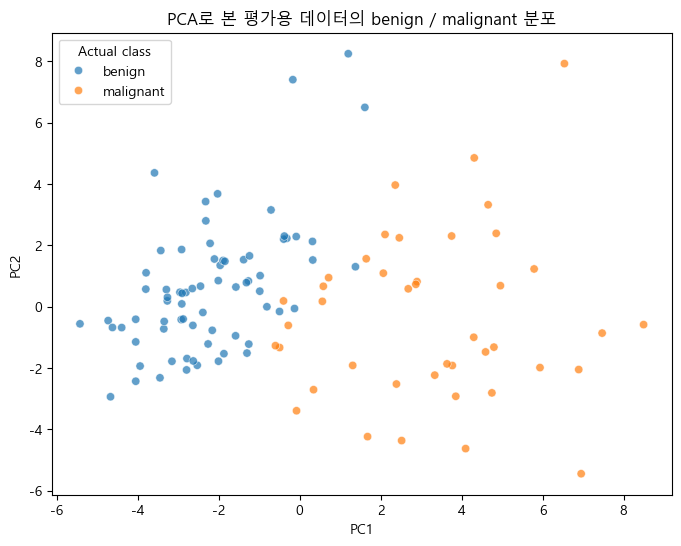

In [24]:
plt.figure(figsize=(8, 6))

# 평가용 데이터를 PC1(가로), PC2(세로) 위치에 점으로 찍습니다.
# hue="y_true_name" 으로 실제 정답(benign/malignant)에 따라 색을 다르게 합니다.
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="y_true_name",    # 실제 class에 따라 색 구분
    alpha=0.7              # 점을 약간 투명하게 (겹침을 보기 위해)
)

plt.title("PCA로 본 평가용 데이터의 benign / malignant 분포")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Actual class")   # 색상이 '실제 정답'을 의미함을 범례로 표시
plt.show()

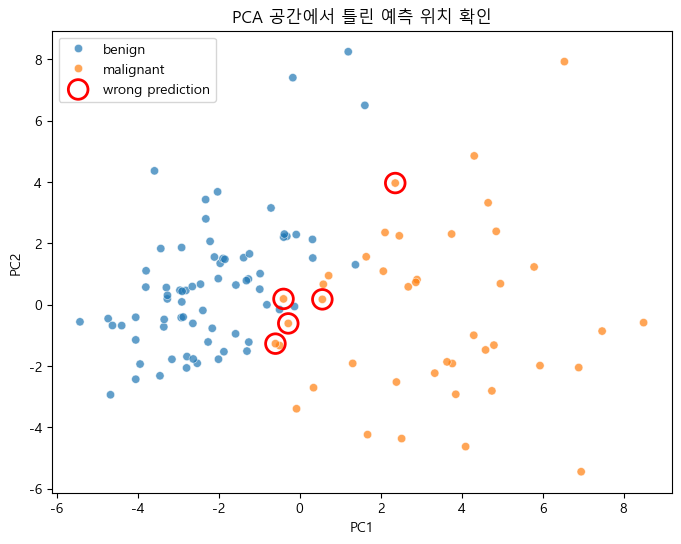

In [25]:
plt.figure(figsize=(8, 6))

# (1) 먼저 전체 평가용 데이터를 실제 class별 색으로 그립니다. (앞 그림과 동일)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="y_true_name",
    alpha=0.7
)

# (2) 틀린 예측만 따로 골라냅니다. (is_correct가 False인 행)
wrong_pca_df = pca_df[pca_df["is_correct"] == False]

# (3) 틀린 데이터가 있을 때만 그 위에 빨간 원으로 크게 표시합니다.
if len(wrong_pca_df) > 0:
    plt.scatter(
        wrong_pca_df["PC1"],
        wrong_pca_df["PC2"],
        s=200,                  # 점 크기를 크게
        facecolors="none",      # 속은 비우고
        edgecolors="red",       # 테두리만 빨간색
        linewidths=2,
        label="wrong prediction"
    )

plt.title("PCA 공간에서 틀린 예측 위치 확인")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()   # 실제 class 색상과 'wrong prediction' 표시를 범례로 보여줍니다.
plt.show()

## 10. threshold 조정으로 FN 줄이기 (기준값을 바꾸면 예측이 달라진다)

In [26]:
# threshold마다 confusion matrix와 classification report를 확인합니다.
#
# 이 셀의 목적은 threshold를 낮출 때
# 1) FN이 줄어드는지
# 2) FP가 늘어나는지
# 3) malignant recall / precision이 어떻게 바뀌는지
# 확인하는 것입니다.

from sklearn.metrics import confusion_matrix, classification_report

# threshold는 malignant라고 판단하는 기준값입니다.
# 기본값은 보통 0.5입니다.
# 여기서는 threshold를 점점 낮춰 보면서 결과가 어떻게 달라지는지 확인합니다.
threshold_list = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.001]

In [27]:
for threshold in threshold_list:
    print("=" * 70)
    print(f"threshold = {threshold}")
    print("=" * 70)

    # malignant 확률이 threshold 이상이면 malignant(1)로 예측합니다.
    # threshold보다 작으면 benign(0)으로 예측합니다.
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    # confusion matrix를 계산합니다.
    # 행 = 실제값, 열 = 예측값
    # labels=[0, 1]을 넣어 benign, malignant 순서를 고정합니다.
    cm_threshold = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels=[0, 1]
    )

    # confusion matrix를 표 형태로 바꿔서 보여줍니다.
    # 숫자 배열보다 표가 초보자에게 더 이해하기 쉽습니다.
    cm_df = pd.DataFrame(
        cm_threshold,
        index=["Actual benign", "Actual malignant"],
        columns=["Predicted benign", "Predicted malignant"]
    )

    print("\n[Confusion Matrix]")
    display(cm_df)

    # confusion matrix에서 FN과 FP를 꺼냅니다.
    # 이 threshold 실험에서 가장 중요하게 볼 값입니다.
    fp = cm_threshold[0, 1]  # 실제 benign인데 malignant로 잘못 예측
    fn = cm_threshold[1, 0]  # 실제 malignant인데 benign으로 잘못 예측

    print(
        f"[핵심 해석] threshold={threshold} → "
        f"FN={fn}개(악성을 양성으로 놓침), "
        f"FP={fp}개(양성을 악성으로 잘못 의심)"
    )

    # classification report를 출력합니다.
    # 여기서는 특히 malignant 행의 recall과 precision을 확인합니다.
    print("\n[Classification Report]")
    print(
        classification_report(
            y_test,
            y_pred_threshold,
            labels=[0, 1],
            target_names=["benign", "malignant"],
            zero_division=0
        )
    )

    print()

threshold = 0.5

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,72,0
Actual malignant,5,37


[핵심 해석] threshold=0.5 → FN=5개(악성을 양성으로 놓침), FP=0개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       0.94      1.00      0.97        72
   malignant       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114


threshold = 0.4

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,72,0
Actual malignant,3,39


[핵심 해석] threshold=0.4 → FN=3개(악성을 양성으로 놓침), FP=0개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        72
   malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


threshold = 0.3

[Confusion Matrix]


...

[핵심 해석] threshold=0.05 → FN=1개(악성을 양성으로 놓침), FP=4개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       0.99      0.94      0.96        72
   malignant       0.91      0.98      0.94        42

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


threshold = 0.01

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,60,12
Actual malignant,1,41


[핵심 해석] threshold=0.01 → FN=1개(악성을 양성으로 놓침), FP=12개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       0.98      0.83      0.90        72
   malignant       0.77      0.98      0.86        42

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.88       114
weighted avg       0.91      0.89      0.89       114


threshold = 0.001

[Confusion Matrix]


,Predicted benign,Predicted malignant
Actual benign,44,28
Actual malignant,0,42


[핵심 해석] threshold=0.001 → FN=0개(악성을 양성으로 놓침), FP=28개(양성을 악성으로 잘못 의심)

[Classification Report]
              precision    recall  f1-score   support

      benign       1.00      0.61      0.76        72
   malignant       0.60      1.00      0.75        42

    accuracy                           0.75       114
   macro avg       0.80      0.81      0.75       114
weighted avg       0.85      0.75      0.76       114


